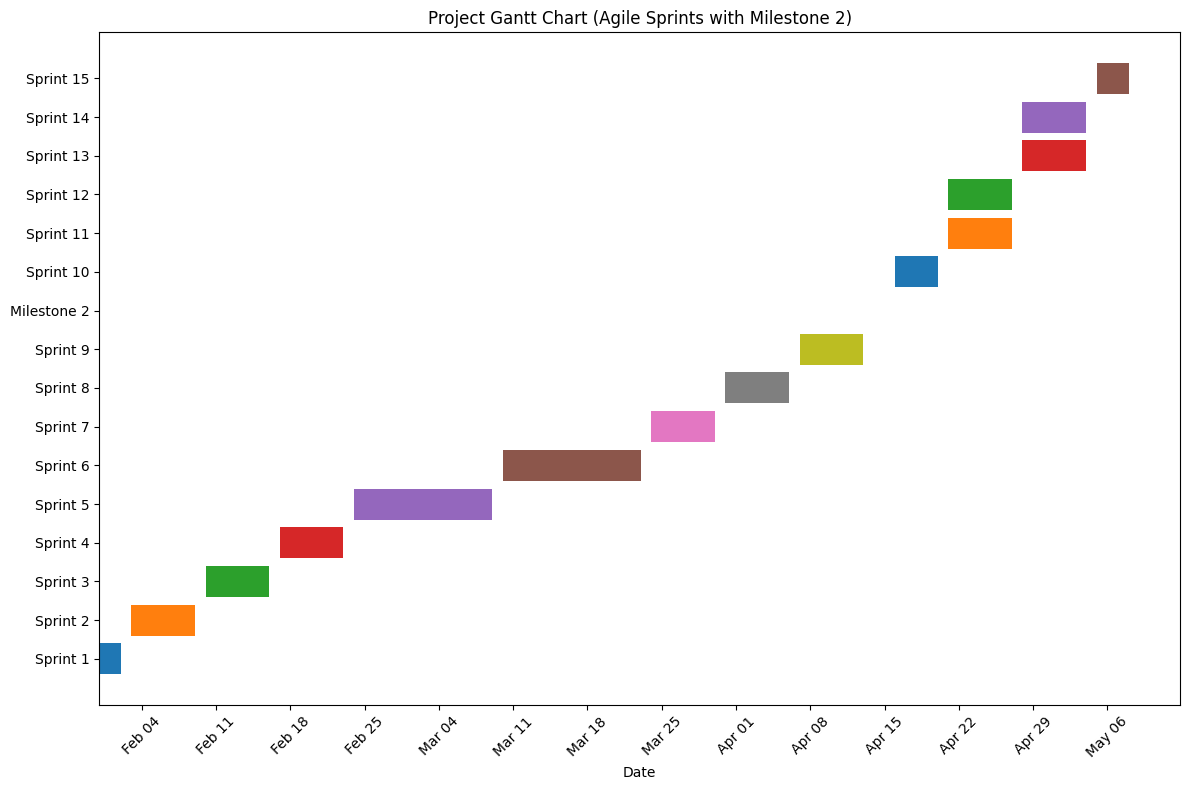

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Define the updated sprints and their date ranges
sprint_data = [
    ("Sprint 1", "Project Initialization", "2025-01-31", "2025-02-02"),
    ("Sprint 2", "Env Setup & Bronze Ingestion", "2025-02-03", "2025-02-09"),
    ("Sprint 3", "Bronze Layer Development", "2025-02-10", "2025-02-16"),
    ("Sprint 4", "Silver Layer Cleaning", "2025-02-17", "2025-02-23"),
    ("Sprint 5", "PII Masking & Parquet", "2025-02-24", "2025-03-09"),
    ("Sprint 6", "Finalize Silver Layer", "2025-03-10", "2025-03-23"),
    ("Sprint 7", "Begin Gold Layer", "2025-03-24", "2025-03-30"),
    ("Sprint 8", "Complete Gold Layer", "2025-03-31", "2025-04-06"),
    ("Sprint 9", "PostgreSQL & Grafana Setup", "2025-04-07", "2025-04-13"),
    ("Milestone 2", "Progress Review", "2025-04-15", "2025-04-15"),
    ("Sprint 10", "Airflow DAG 1 - Bronze", "2025-04-16", "2025-04-20"),
    ("Sprint 11", "Airflow DAGs 2 & 3 - Silver & Gold", "2025-04-21", "2025-04-27"),
    ("Sprint 12", "Automation to PostgreSQL", "2025-04-21", "2025-04-27"),
    ("Sprint 13", "Grafana Dashboard Integration", "2025-04-28", "2025-05-04"),
    ("Sprint 14", "Documentation & QA", "2025-04-28", "2025-05-04"),
    ("Sprint 15", "Final Presentation", "2025-05-05", "2025-05-08"),
]

# Create DataFrame
df = pd.DataFrame(sprint_data, columns=["Sprint", "Task", "Start", "End"])
df["Start"] = pd.to_datetime(df["Start"])
df["End"] = pd.to_datetime(df["End"])

# Create Gantt chart
fig, ax = plt.subplots(figsize=(12, 8))
for i, row in df.iterrows():
    ax.barh(row["Sprint"], (row["End"] - row["Start"]).days, left=row["Start"], label=row["Task"])

# Formatting
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=45)
ax.set_xlabel("Date")
ax.set_title("Project Gantt Chart (Agile Sprints with Milestone 2)")
plt.tight_layout()

plt.show()


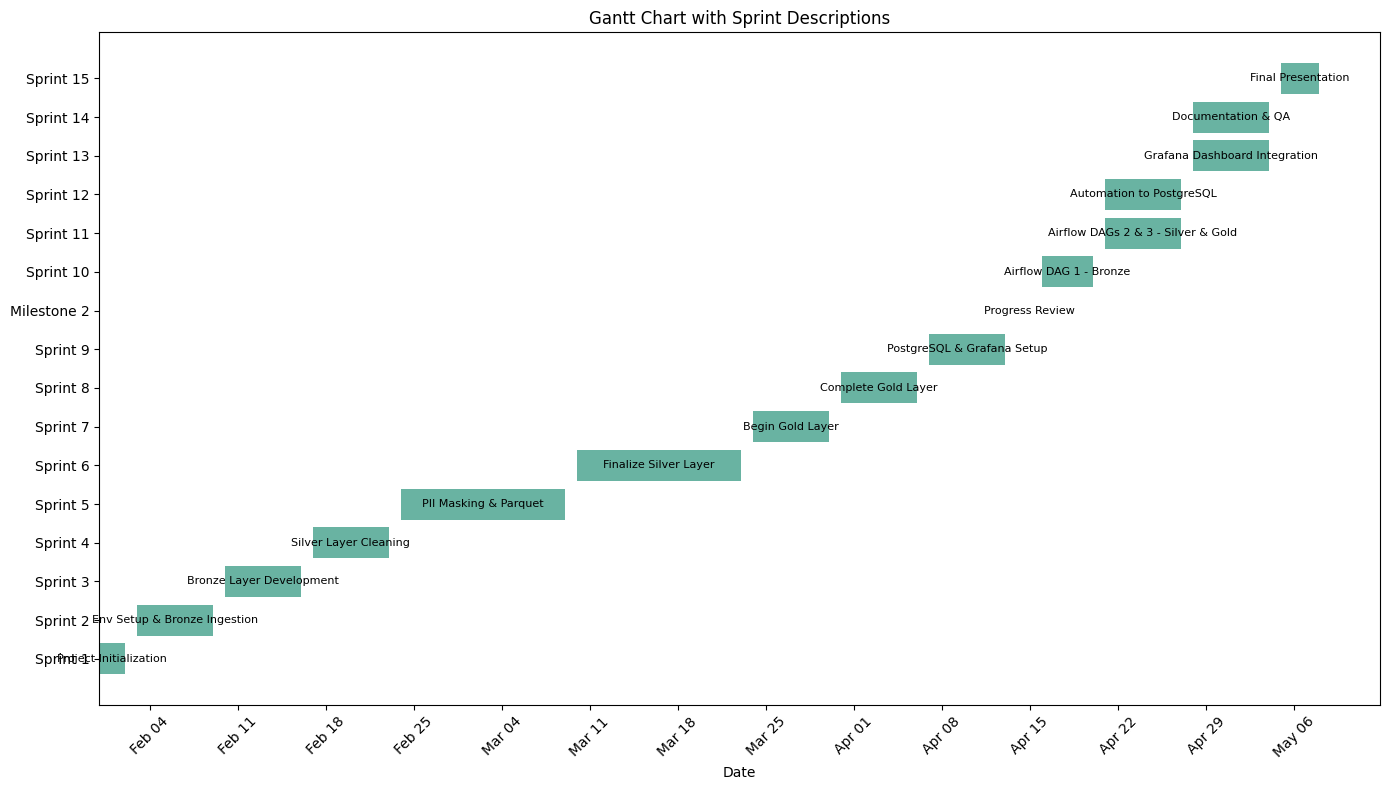

In [2]:
# Create revised Gantt chart with task descriptions shown on the bars
fig, ax = plt.subplots(figsize=(14, 8))

for i, row in df.iterrows():
    duration = (row["End"] - row["Start"]).days
    bar = ax.barh(row["Sprint"], duration, left=row["Start"], color="#69b3a2")
    ax.text(row["Start"] + pd.Timedelta(days=duration / 2), i, row["Task"],
            va='center', ha='center', fontsize=8, color='black')

# Formatting
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=45)
ax.set_xlabel("Date")
ax.set_title("Gantt Chart with Sprint Descriptions")
plt.tight_layout()

plt.show()


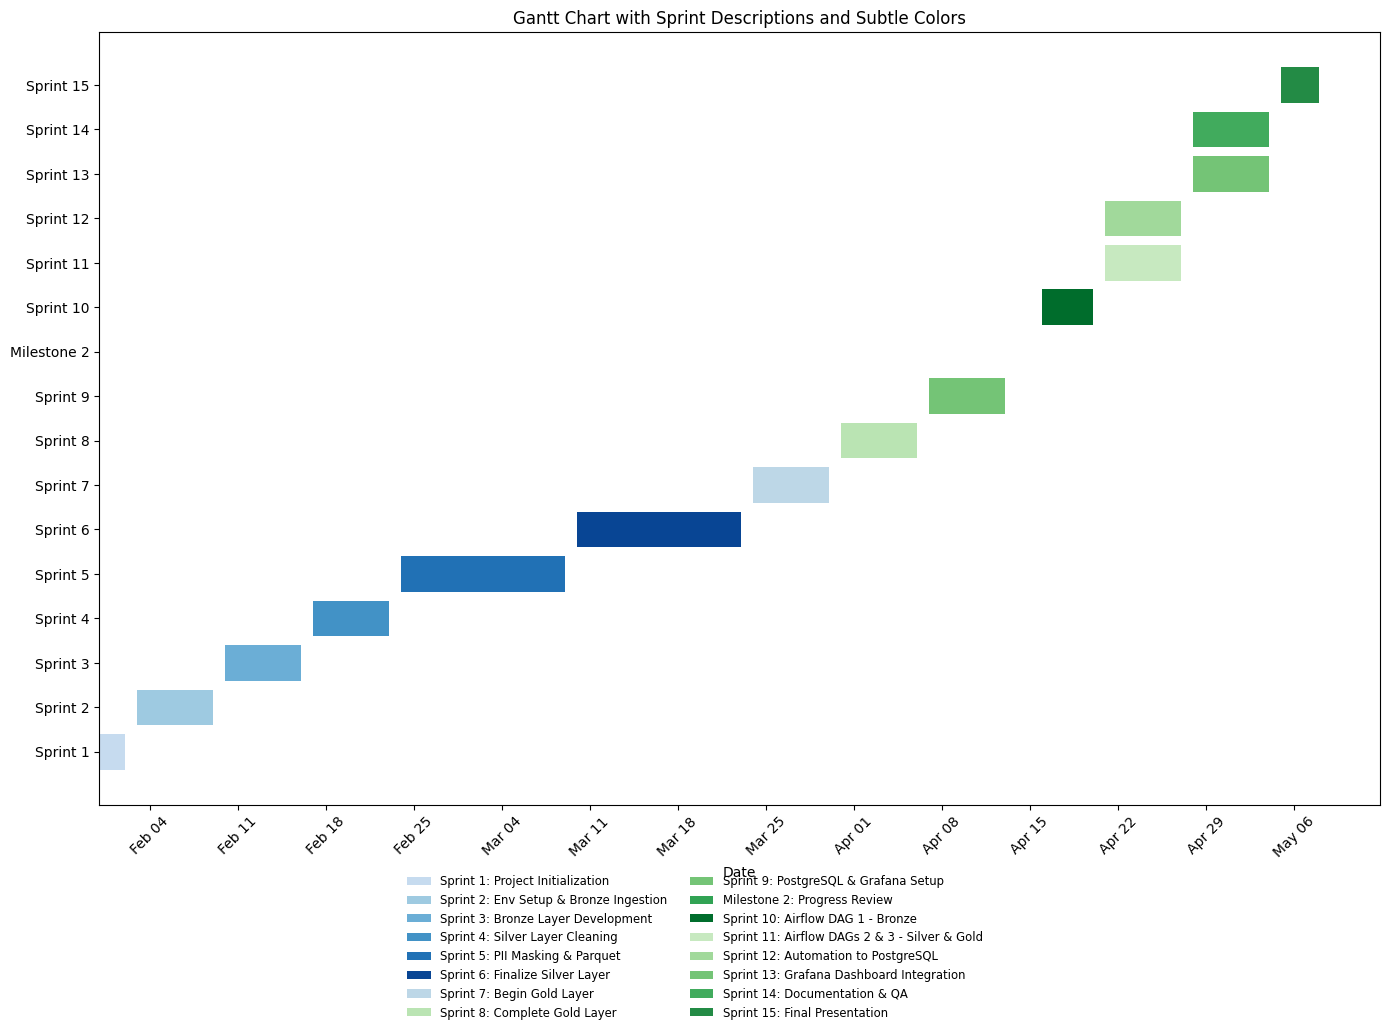

In [3]:
# Define subtle colors for better aesthetics
colors = [
    "#c6dbef", "#9ecae1", "#6baed6", "#4292c6", "#2171b5",
    "#084594", "#bdd7e7", "#bae4b3", "#74c476", "#31a354",
    "#006d2c", "#c7e9c0", "#a1d99b", "#74c476", "#41ab5d", "#238b45"
]

# Create revised Gantt chart with subtle colors and legend
fig, ax = plt.subplots(figsize=(14, 9))

# Plot bars with subtle colors
for i, row in df.iterrows():
    duration = (row["End"] - row["Start"]).days
    color = colors[i % len(colors)]
    ax.barh(row["Sprint"], duration, left=row["Start"], color=color)
    
# Create a legend below the chart
legend_labels = [f"{row['Sprint']}: {row['Task']}" for _, row in df.iterrows()]
fig.legend(legend_labels, loc='lower center', bbox_to_anchor=(0.5, -0.15),
           fontsize='small', frameon=False, ncol=2)

# Formatting
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=45)
ax.set_xlabel("Date")
ax.set_title("Gantt Chart with Sprint Descriptions and Subtle Colors")
plt.tight_layout()

plt.show()


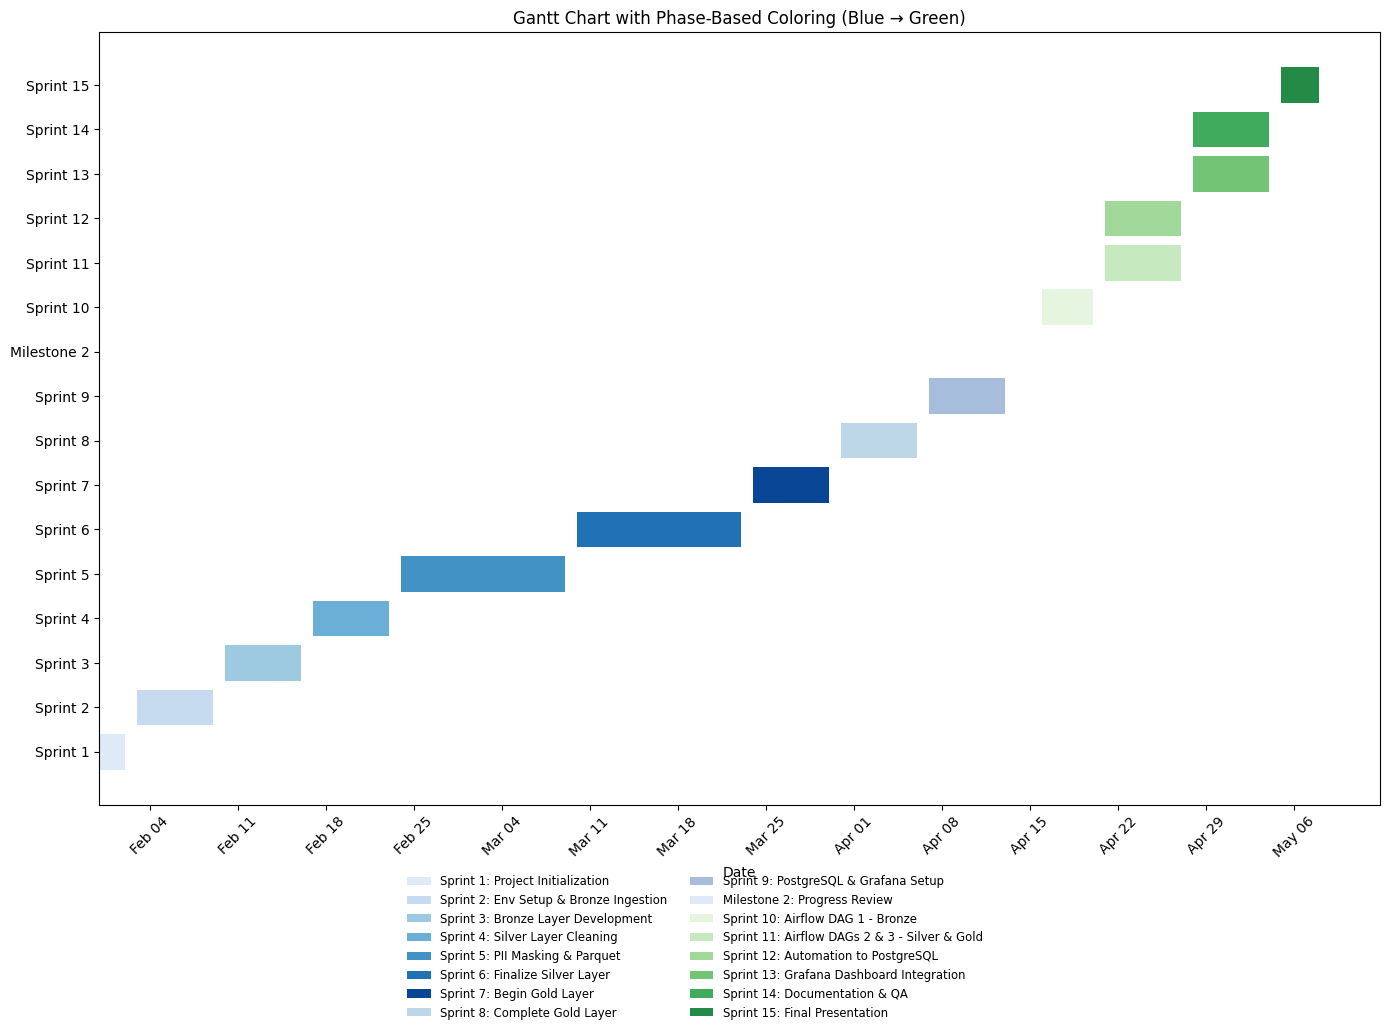

In [4]:
# Define shades of blue for sprints up to Milestone 2 (index 0 to 8), and shades of green for the rest
blue_shades = ["#deebf7", "#c6dbef", "#9ecae1", "#6baed6", "#4292c6", "#2171b5", "#084594", "#bdd7e7", "#a6bddb"]
green_shades = ["#e5f5e0", "#c7e9c0", "#a1d99b", "#74c476", "#41ab5d", "#238b45", "#006d2c"]

# Create revised Gantt chart with color switch at milestone
fig, ax = plt.subplots(figsize=(14, 9))

# Plot bars with appropriate colors
for i, row in df.iterrows():
    duration = (row["End"] - row["Start"]).days
    # Use blue for sprints before and including milestone, green after
    if i <= 9:  # up to Milestone 2
        color = blue_shades[i % len(blue_shades)]
    else:
        color = green_shades[(i - 10) % len(green_shades)]
    ax.barh(row["Sprint"], duration, left=row["Start"], color=color)

# Create a legend below the chart
legend_labels = [f"{row['Sprint']}: {row['Task']}" for _, row in df.iterrows()]
fig.legend(legend_labels, loc='lower center', bbox_to_anchor=(0.5, -0.15),
           fontsize='small', frameon=False, ncol=2)

# Formatting
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=45)
ax.set_xlabel("Date")
ax.set_title("Gantt Chart with Phase-Based Coloring (Blue → Green)")
plt.tight_layout()

plt.show()


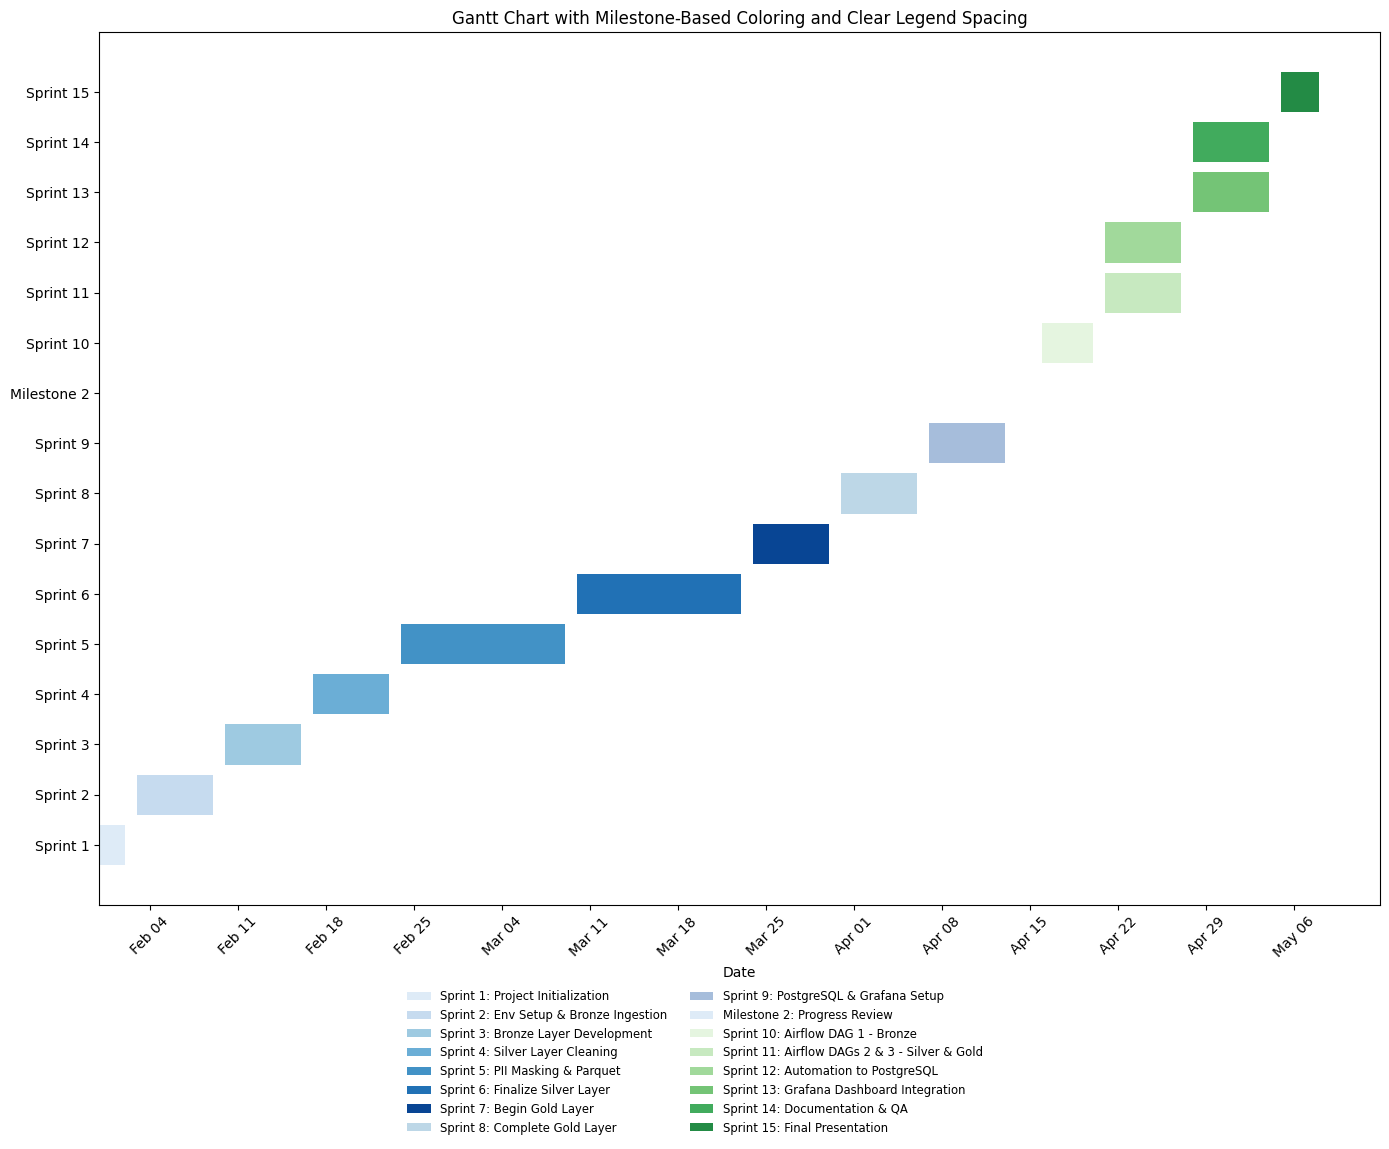

In [5]:
# Create revised Gantt chart with extra space for the legend
fig, ax = plt.subplots(figsize=(14, 10))  # Increase figure height

# Plot bars with blue and green shades based on milestone
for i, row in df.iterrows():
    duration = (row["End"] - row["Start"]).days
    if i <= 9:  # up to and including Milestone 2
        color = blue_shades[i % len(blue_shades)]
    else:
        color = green_shades[(i - 10) % len(green_shades)]
    ax.barh(row["Sprint"], duration, left=row["Start"], color=color)

# Create a legend below the chart with added vertical space
legend_labels = [f"{row['Sprint']}: {row['Task']}" for _, row in df.iterrows()]
fig.subplots_adjust(bottom=0.25)  # Add more space below for legend
fig.legend(legend_labels, loc='lower center', bbox_to_anchor=(0.5, -0.15),
           fontsize='small', frameon=False, ncol=2)

# Formatting
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=45)
ax.set_xlabel("Date")
ax.set_title("Gantt Chart with Milestone-Based Coloring and Clear Legend Spacing")
plt.tight_layout()

plt.show()


In [14]:
from datetime import timedelta

# Shift the entire timeline to start from February 7, 2025
adjusted_start_date = pd.to_datetime("2025-02-07")
current_date = adjusted_start_date

# Recalculate sprint schedule with new start date
adjusted_schedule = []
for i, (task, duration) in enumerate(zip(final_tasks, final_durations)):
    if duration == 0:
        sprint_name = "Milestone 2"
        sprint_start = pd.to_datetime("2025-04-15")
        sprint_end = sprint_start
    else:
        sprint_name = f"Sprint {i+1 if i < 5 else i}"
        sprint_start = current_date
        sprint_end = current_date + timedelta(days=duration - 1)
        current_date = sprint_end + timedelta(days=1)
    adjusted_schedule.append((sprint_name, task, sprint_start, sprint_end))

# Create DataFrame
df_adjusted = pd.DataFrame(adjusted_schedule, columns=["Sprint", "Task", "Start", "End"])

# Display the updated sprint schedule
import ace_tools as tools; tools.display_dataframe_to_user(name="Adjusted Sprint Plan", dataframe=df_adjusted)


ModuleNotFoundError: No module named 'ace_tools'